## Classification Exploration 6: Multi-Layer Perceptron

# [Classification: Multi-Layer Perceptron Classifier](https://en.wikipedia.org/wiki/Multilayer_perceptron)

The IBM HR Analytics Employee Attrition dataset contains fictional data created by IBM data scientists. 
It includes 1,470 employee records with 35 features covering demographics, job roles, satisfaction levels, 
and compensation. The target variable is **Attrition** — whether an employee left the company (Yes/No).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
%matplotlib inline
plt.style.use('ggplot')

df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Drop constant columns
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'])

# Encode categorical columns
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField',
                                  'Gender', 'JobRole', 'MaritalStatus', 'OverTime'],
                    drop_first=True)

# Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     test_size=0.30,
                                                     stratify=y,
                                                     random_state=123)

# Scale data — MLP is sensitive to feature magnitudes
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)

(1029, 44) (441, 44)


## Multi-Layer Perceptron Classifier

In [3]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(5, 3, 2),
                      activation='relu',
                      alpha=0.001,
                      batch_size='auto',
                      learning_rate='constant',
                      max_iter=200,
                      solver='sgd',
                      tol=0.01,
                      verbose=True)

# hidden_layer_sizes: number of neurons in each hidden layer
# activation: 'identity', 'logistic', 'tanh', 'relu'
# alpha: L2 regularization term
# solver: 'sgd', 'adam', 'lbfgs'
# max_iter: maximum number of iterations

In [4]:
# DEFINE YOUR CLASSIFIER and THE PARAMETERS GRID
classifier = MLPClassifier()
parameters = {"hidden_layer_sizes": [(5, 3, 2), (5, 3)],
              "max_iter": [500000],
              "alpha": [0.1, 1, 10]}

In [5]:
# DEFINE YOUR GRIDSEARCH
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(classifier, parameters, cv=3, scoring='f1', verbose=50, n_jobs=-1, refit=True)

In [6]:
# TRAIN YOUR CLASSIFIER
gs = gs.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV 1/3; 1/6] START alpha=0.1, hidden_layer_sizes=(5, 3, 2), max_iter=500000....
[CV 2/3; 1/6] START alpha=0.1, hidden_layer_sizes=(5, 3, 2), max_iter=500000....
[CV 1/3; 2/6] START alpha=0.1, hidden_layer_sizes=(5, 3), max_iter=500000.......
[CV 3/3; 1/6] START alpha=0.1, hidden_layer_sizes=(5, 3, 2), max_iter=500000....
[CV 2/3; 3/6] START alpha=1, hidden_layer_sizes=(5, 3, 2), max_iter=500000......
[CV 1/3; 3/6] START alpha=1, hidden_layer_sizes=(5, 3, 2), max_iter=500000......
[CV 2/3; 2/6] START alpha=0.1, hidden_layer_sizes=(5, 3), max_iter=500000.......
[CV 3/3; 2/6] START alpha=0.1, hidden_layer_sizes=(5, 3), max_iter=500000.......
[CV 3/3; 3/6] START alpha=1, hidden_layer_sizes=(5, 3, 2), max_iter=500000......
[CV 1/3; 4/6] START alpha=1, hidden_layer_sizes=(5, 3), max_iter=500000.........
[CV 1/3; 3/6] END alpha=1, hidden_layer_sizes=(5, 3, 2), max_iter=500000;, score=0.409 total time=   0.4s
[CV 2/3; 4/6] START alph

In [7]:
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))

means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']

for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

***GRIDSEARCH RESULTS***
Best score: 0.428467 using {'alpha': 0.1, 'hidden_layer_sizes': (5, 3, 2), 'max_iter': 500000}
0.428467 (0.077520) with: {'alpha': 0.1, 'hidden_layer_sizes': (5, 3, 2), 'max_iter': 500000}
0.410448 (0.029593) with: {'alpha': 0.1, 'hidden_layer_sizes': (5, 3), 'max_iter': 500000}
0.378040 (0.086641) with: {'alpha': 1, 'hidden_layer_sizes': (5, 3, 2), 'max_iter': 500000}
0.412429 (0.064332) with: {'alpha': 1, 'hidden_layer_sizes': (5, 3), 'max_iter': 500000}
0.000000 (0.000000) with: {'alpha': 10, 'hidden_layer_sizes': (5, 3, 2), 'max_iter': 500000}
0.148185 (0.104823) with: {'alpha': 10, 'hidden_layer_sizes': (5, 3), 'max_iter': 500000}


In [8]:
#TEST ON YOUR TEST SET
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test_scaled)
y_pred_train = best_model.predict(X_train_scaled)

In [9]:
#EVALUATE YOUR PREDICTION
print('***RESULTS ON TRAIN SET***')
print("f1_score: ", metrics.f1_score(y_train, y_pred_train))
print("--")
print('***RESULTS ON TEST SET***')
print("f1_score: ", metrics.f1_score(y_test, y_pred))

***RESULTS ON TRAIN SET***
f1_score:  0.8430769230769231
--
***RESULTS ON TEST SET***
f1_score:  0.5899280575539568


In [10]:
#PRINT SOME FURTHER METRICS
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.92       370
           1       0.60      0.58      0.59        71

    accuracy                           0.87       441
   macro avg       0.76      0.75      0.76       441
weighted avg       0.87      0.87      0.87       441



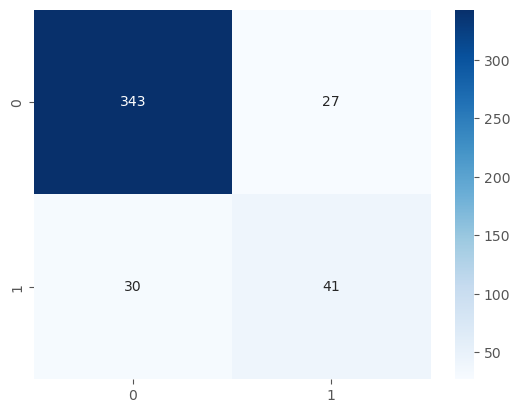

In [11]:
#CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.show()

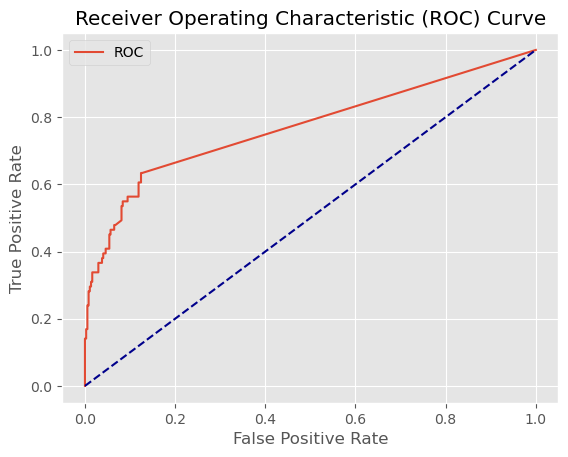

AUC: 0.77


In [12]:
from sklearn import metrics

model = MLPClassifier(hidden_layer_sizes=(5, 3, 2), alpha=0.1, max_iter=500000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_probs = model.predict_proba(X_test_scaled)

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_probs[:, 1])

plt.plot(fpr, tpr, label='ROC')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

auc = metrics.roc_auc_score(y_test, y_probs[:, 1])
print('AUC: %.2f' % auc)

## Summary

In this notebook we applied a Multi-Layer Perceptron (MLP) classifier to predict employee attrition using the IBM HR dataset.

Despite being a neural network, MLP underperformed compared to Logistic Regression and SVM:

- **F1 train = 0.84, F1 test = 0.59** — significant overfitting despite regularization
- **AUC = 0.77** — below Logistic Regression and SVM

Updated leaderboard:

| Model | F1 Test | AUC |
|-------|---------|-----|
| KNN | 0.22 | 0.54 |
| Decision Tree | 0.44 | 0.69 |
| Naive Bayes | 0.44 | 0.74 |
| MLP | 0.59 | 0.77 |
| SVM | 0.60 | 0.86 |
| Logistic Regression | 0.61 | 0.86 |

Key findings from the GridSearch:
- **Best architecture**: (5, 3, 2) with alpha=0.1 — three hidden layers with very few neurons
- **alpha=10** completely collapsed the model to F1=0.0 — too much regularization prevented any learning
- The small network size limits the model's capacity to capture complex patterns

The main limitations here are the small network architecture and the dataset size — neural networks typically shine with much larger datasets. With only 1,470 samples, simpler models like Logistic Regression generalize better.

The final notebook will explore an ensemble method to see if we can push performance beyond the current best of AUC=0.86.